In [16]:
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath("../"))

from src.data.load_data import load_ratings, load_movies, load_tags

DATA_PATH = "../data/raw"

In [6]:
# load data

ratings = load_ratings(DATA_PATH)
movies = load_movies(DATA_PATH)
tags = load_tags(DATA_PATH)

print(ratings.shape)
print(movies.shape)
print(tags.shape)

(32000204, 4)
(87585, 3)
(2000072, 4)


In [7]:
# basic stats

print("Users:", ratings["userId"].nunique())
print("Movies:", ratings["movieId"].nunique())
print("Ratings:", len(ratings))

Users: 200948
Movies: 84432
Ratings: 32000204


In [8]:
# sparsity

num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()

sparsity = 1 - (len(ratings) / (num_users * num_movies))
print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9981


<Axes: >

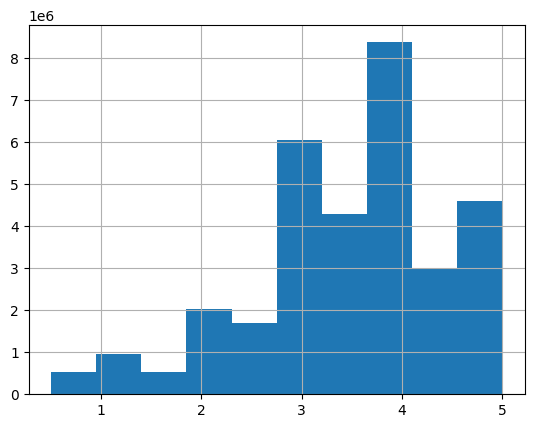

In [9]:
# rating distribution

ratings["rating"].hist(bins=10)

In [10]:
# ratings per user

ratings_per_user = ratings.groupby("userId").size()
ratings_per_user.describe()

count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
dtype: float64

In [11]:
# ratings per movie

ratings_per_movie = ratings.groupby("movieId").size()
ratings_per_movie.describe()

count     84432.000000
mean        379.005638
std        2592.439791
min           1.000000
25%           2.000000
50%           5.000000
75%          25.000000
max      102929.000000
dtype: float64

In [14]:
# most popular movies

popular_movies = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")   # ✅ convert to DataFrame
    .sort_values(by="rating_count", ascending=False)
    .head(10)
)

popular_movies = popular_movies.merge(movies, on="movieId")

popular_movies

,movieId,rating_count,title,genres
0,318,102929,"Shawshank Redemption, The (1994)",Crime|Drama
1,356,100296,Forrest Gump (1994),Comedy|Drama|Romance|War
2,296,98409,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,2571,93808,"Matrix, The (1999)",Action|Sci-Fi|Thriller
4,593,90330,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
5,260,85010,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,2959,77332,Fight Club (1999),Action|Crime|Drama|Thriller
7,480,75233,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
8,527,73849,Schindler's List (1993),Drama|War
9,4993,73122,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy


In [17]:
# timestamp analysis

ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["timestamp"].min(), ratings["timestamp"].max()

(Timestamp('1995-01-09 11:46:44'), Timestamp('2023-10-13 02:29:07'))